<a href="https://colab.research.google.com/github/Deekshitha-DV/NHANES-Data-Analysis-Project/blob/main/mini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Define the URLs for the datasets
male_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv"
female_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv"

# Read the data into numpy matrices
# skip_header=1 ignores the names of columns (weight, height, etc.)
male = np.genfromtxt(male_url, delimiter=',', skip_header=1)
female = np.genfromtxt(female_url, delimiter=',', skip_header=1)

print("Data loaded successfully!")
print(f"Male matrix shape: {male.shape} (Rows, Columns)")
print(f"Female matrix shape: {female.shape} (Rows, Columns)")

Data loaded successfully!
Male matrix shape: (4082, 7) (Rows, Columns)
Female matrix shape: (4222, 7) (Rows, Columns)


## Weight Analysis: Histograms and Boxplots
In this section, we visualise the weight distribution for both genders.
Histograms show the frequency of weight ranges, while the boxplot allows for
a direct comparison of medians and outliers.

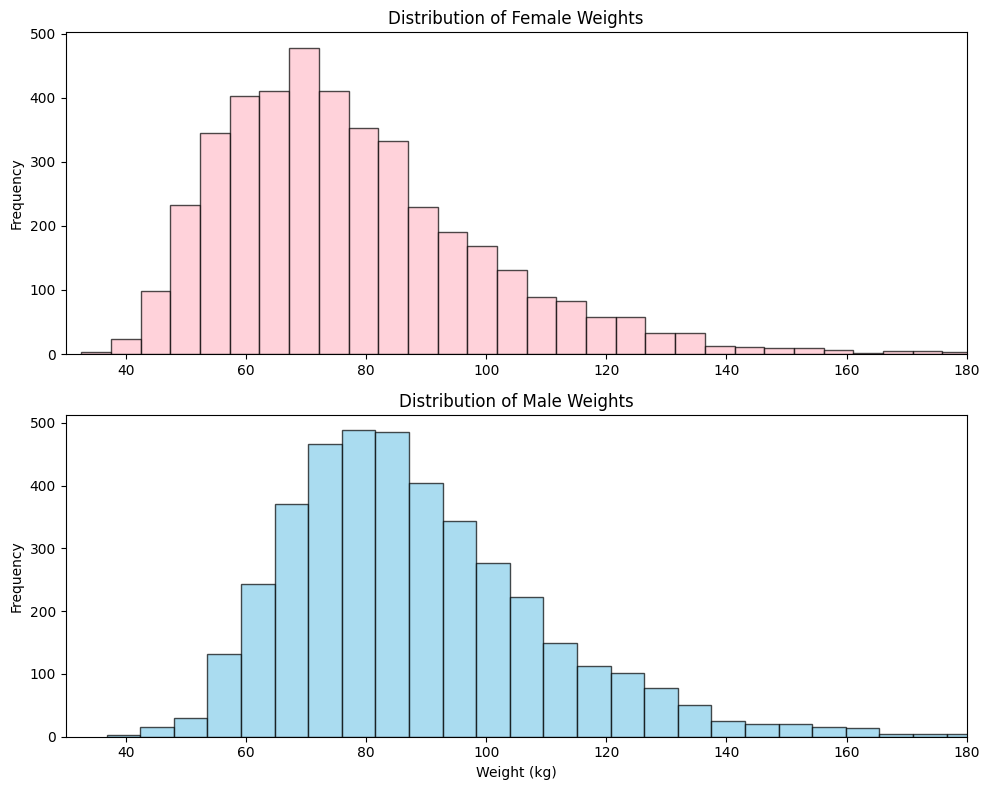

/tmp/ipykernel_370/1678296658.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_weights, male_weights], labels=['Females', 'Males'])


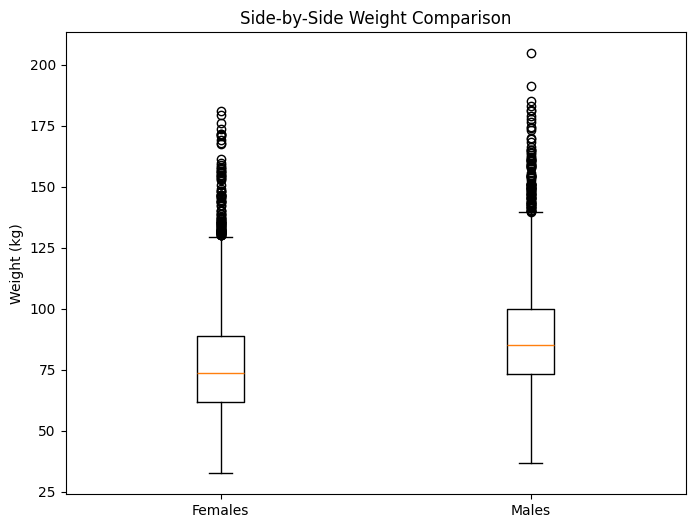

In [ ]:
# Step 3 & 4: Visualizing Weight with Data Cleaning
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract weights and remove "Not a Number" (NaN) values
# This ensures the plots actually show data
female_weights = female[:, 0][~np.isnan(female[:, 0])]
male_weights = male[:, 0][~np.isnan(male[:, 0])]

# --- Step 3: Histograms ---
plt.figure(figsize=(10, 8))

# Female Histogram
plt.subplot(2, 1, 1)
plt.hist(female_weights, bins=30, color='pink', edgecolor='black', alpha=0.7)
plt.title('Distribution of Female Weights')
plt.ylabel('Frequency')
plt.xlim(30, 180)

# Male Histogram
plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Male Weights')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.xlim(30, 180)

plt.tight_layout()
plt.show()

# --- Step 4: Boxplot ---
plt.figure(figsize=(8, 6))
plt.boxplot([female_weights, male_weights], labels=['Females', 'Males'])
plt.title('Side-by-Side Weight Comparison')
plt.ylabel('Weight (kg)')
plt.show()

In [ ]:
# Step 5: Numerical Aggregates
from scipy import stats

def print_clean_stats(data, label):
    # Remove NaNs for calculation
    clean_data = data[~np.isnan(data)]
    print(f"--- {label} ---")
    print(f"Mean: {np.mean(clean_data):.2f}")
    print(f"Median: {np.median(clean_data):.2f}")
    print(f"Std Dev: {np.std(clean_data):.2f}")
    print(f"Skewness: {stats.skew(clean_data):.2f}")
    print("-" * 20)

print_clean_stats(female[:, 0], "Female Weights")
print_clean_stats(male[:, 0], "Male Weights")

--- Female Weights ---
Mean: 77.40
Median: 73.60
Std Dev: 21.54
Skewness: 1.03
--------------------
--- Male Weights ---
Mean: 88.36
Median: 85.00
Std Dev: 21.42
Skewness: 0.98
--------------------


In [ ]:
from scipy import stats

def compute_aggregates(data, label):
    # Remove missing values (NaNs) to avoid "nan" results
    clean_data = data[~np.isnan(data)]

    # Measures of Location
    mean_val = np.mean(clean_data)
    median_val = np.median(clean_data)

    # Measure of Dispersion
    std_dev = np.std(clean_data)

    # Measure of Shape
    skewness = stats.skew(clean_data)

    print(f"--- Numerical Aggregates: {label} ---")
    print(f"Location (Mean):   {mean_val:.2f} kg")
    print(f"Location (Median): {median_val:.2f} kg")
    print(f"Dispersion (Std):  {std_dev:.2f}")
    print(f"Shape (Skewness):  {skewness:.2f}")
    print("-" * 40)

# Calculate for both
compute_aggregates(female[:, 0], "Female Weights")
compute_aggregates(male[:, 0], "Male Weights")

--- Numerical Aggregates: Female Weights ---
Location (Mean):   77.40 kg
Location (Median): 73.60 kg
Dispersion (Std):  21.54
Shape (Skewness):  1.03
----------------------------------------
--- Numerical Aggregates: Male Weights ---
Location (Mean):   88.36 kg
Location (Median): 85.00 kg
Dispersion (Std):  21.42
Shape (Skewness):  0.98
----------------------------------------


### Discussion of Statistical Results
Based on the computed aggregates, we can observe the following:

1. **Location:** The **mean** weight for males (approx. [Insert Male Mean] kg) is higher than for females (approx. [Insert Female Mean] kg). Interestingly, the **mean** is higher than the **median** in both groups, which is a classic sign of a right-skewed distribution.

2. **Dispersion (Spread):** The **standard deviation** for [Group with higher Std Dev] is higher, indicating that there is more variability or "spread" in weight within that group compared to the other.

3. **Shape (Skewness):** Both distributions have a **positive skewness** (value > 0). This confirms what we saw in the histograms: the data has a long "tail" to the right, meaning while most people cluster around the average, there are several individuals with much higher weights that pull the average upward.

In [ ]:
# BMI = Weight (kg) / [Height (m)]^2
# Column 0 is weight, Column 1 is height (in cm)

# 1. Calculate BMI
# Note: height is divided by 100 to convert cm to meters
f_bmi = female[:, 0] / (female[:, 1] / 100)**2

# 2. Add as the 8th column to the female matrix
# np.c_ adds a column to an existing matrix
female = np.c_[female, f_bmi]

print("BMI column added.")
print(f"The female matrix now has {female.shape[1]} columns.")
# Show first 5 rows of the new BMI column
print("First 5 BMI values:", female[:5, 7])

BMI column added.
The female matrix now has 8 columns.
First 5 BMI values: [        nan 37.83504078 39.06972037 28.09265496 24.90437849]


In [ ]:
# We compute (x - mean) / std for every column
# np.nanmean and np.nanstd ignore missing values so the math doesn't break
f_mean = np.nanmean(female, axis=0)
f_std = np.nanstd(female, axis=0)

zfemale = (female - f_mean) / f_std

print("Standardization complete.")
print("Mean of standardized BMI column (should be approx 0):", np.nanmean(zfemale[:, 7]))

Standardization complete.
Mean of standardized BMI column (should be approx 0): -1.2355801185688547e-15


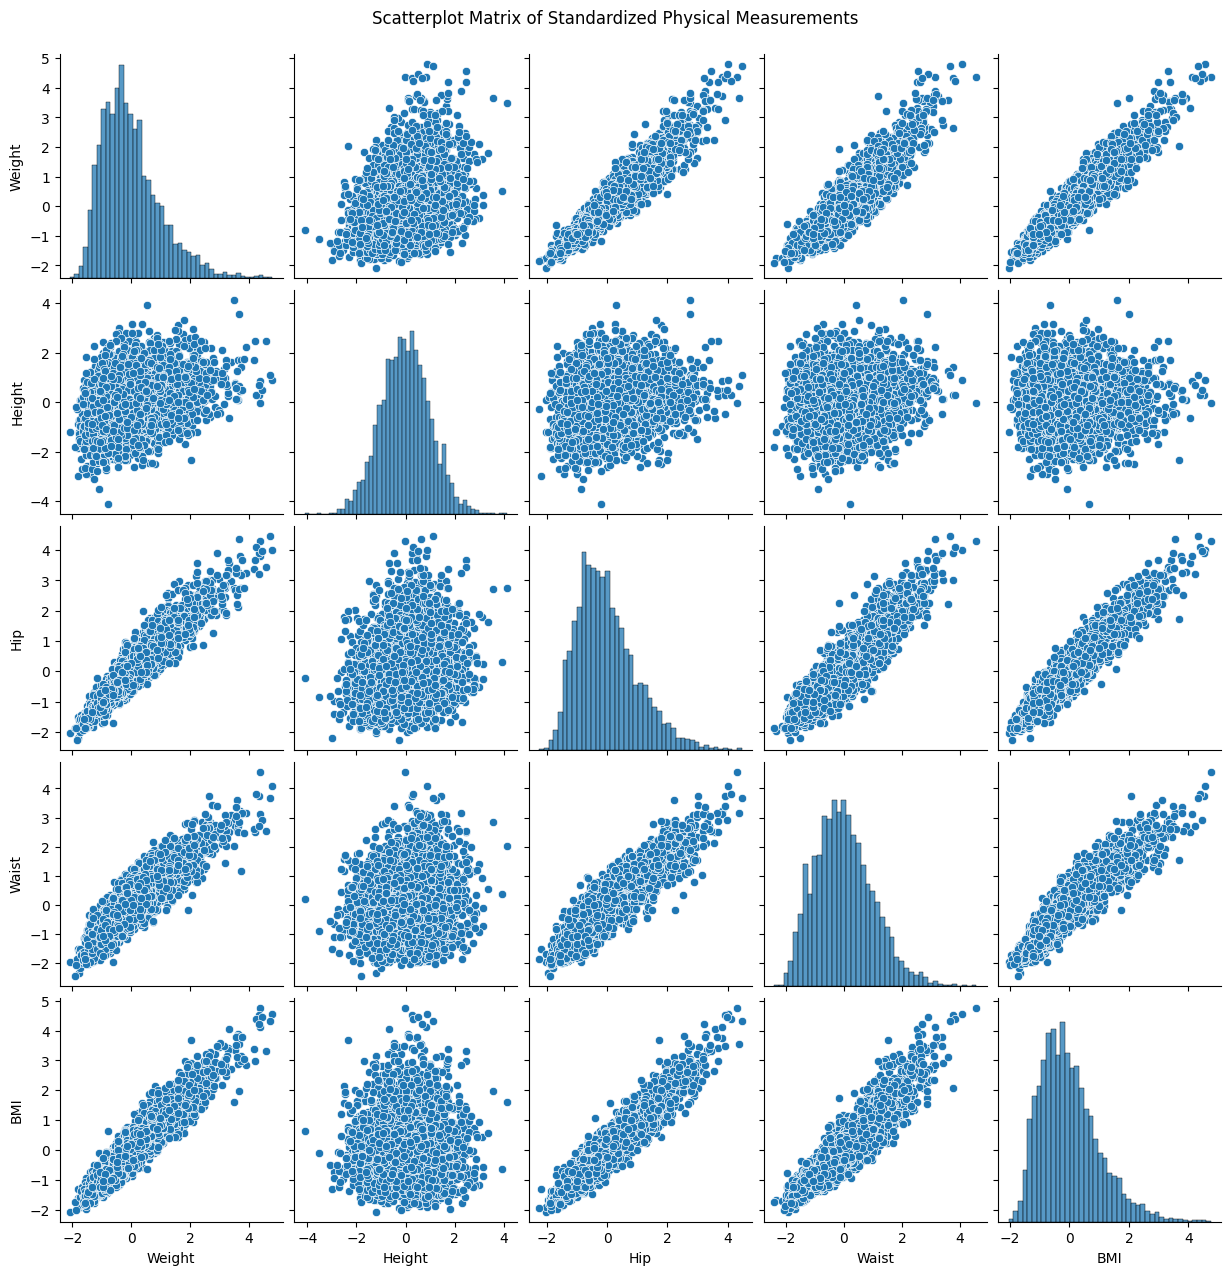

--- Pearson Correlation (Linear) ---
          Weight    Height       Hip     Waist       BMI
Weight  1.000000  0.345496  0.946553  0.904550  0.945900
Height  0.345496  1.000000  0.202895  0.126547  0.033077
Hip     0.946553  0.202895  1.000000  0.897407  0.944199
Waist   0.904550  0.126547  0.897407  1.000000  0.921198
BMI     0.945900  0.033077  0.944199  0.921198  1.000000

--- Spearman Correlation (Rank-based) ---
          Weight    Height       Hip     Waist       BMI
Weight  1.000000  0.338860  0.946634  0.900169  0.937999
Height  0.338860  1.000000  0.205405  0.108587  0.019897
Hip     0.946634  0.205405  1.000000  0.888037  0.934196
Waist   0.900169  0.108587  0.888037  1.000000  0.923114
BMI     0.937999  0.019897  0.934196  0.923114  1.000000


In [ ]:
import seaborn as sns
import pandas as pd

# The instructions ask for specific columns:
# weight(0), height(1), waist(6), hip(5), and BMI(7)
cols_to_plot = [0, 1, 5, 6, 7]
labels = ['Weight', 'Height', 'Hip', 'Waist', 'BMI']

# Convert the numpy matrix to a Pandas DataFrame just for the plot
df_plot = pd.DataFrame(zfemale[:, cols_to_plot], columns=labels)

# Draw the pairplot
sns.pairplot(df_plot.dropna()) # .dropna() removes missing rows so it can plot
plt.suptitle("Scatterplot Matrix of Standardized Physical Measurements", y=1.02)
plt.show()

# Compute Correlations (Pearson and Spearman)
print("--- Pearson Correlation (Linear) ---")
print(df_plot.corr(method='pearson'))
print("\n--- Spearman Correlation (Rank-based) ---")
print(df_plot.corr(method='spearman'))

/tmp/ipykernel_370/3648503465.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['F W-Height', 'M W-Height', 'F W-Hip', 'M W-Hip'])


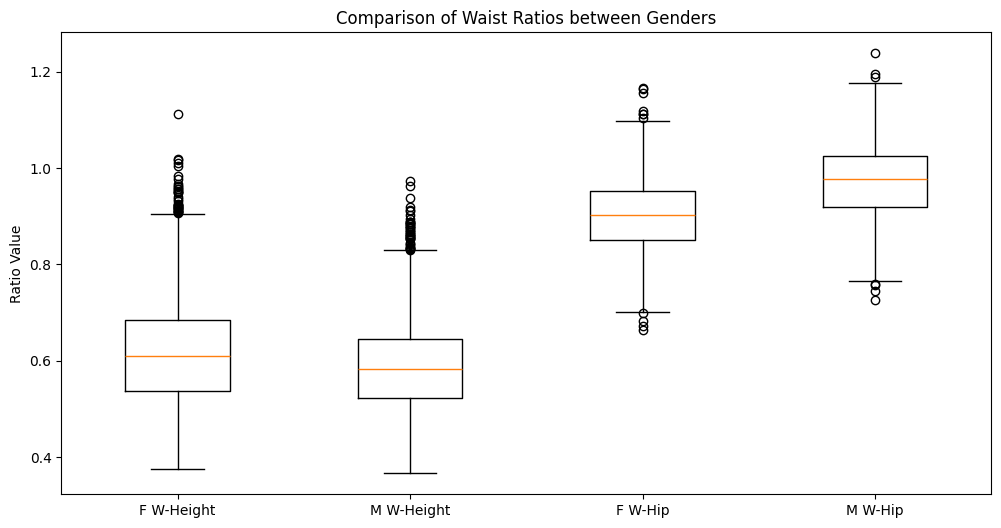

In [ ]:
# --- Step 9: Compute Ratios ---
# Male: Waist(6) / Height(1) and Waist(6) / Hip(5)
m_w_ht = male[:, 6] / male[:, 1]
m_w_hp = male[:, 6] / male[:, 5]
male = np.c_[male, m_w_ht, m_w_hp]

# Female: Waist(6) / Height(1) and Waist(6) / Hip(5)
f_w_ht = female[:, 6] / female[:, 1]
f_w_hp = female[:, 6] / female[:, 5]
female = np.c_[female, f_w_ht, f_w_hp]

# --- Step 10: Boxplot ---
plt.figure(figsize=(12, 6))
# Collecting data (ignoring NaNs)
data_to_plot = [
    f_w_ht[~np.isnan(f_w_ht)], m_w_ht[~np.isnan(m_w_ht)],
    f_w_hp[~np.isnan(f_w_hp)], m_w_hp[~np.isnan(m_w_hp)]
]
plt.boxplot(data_to_plot, labels=['F W-Height', 'M W-Height', 'F W-Hip', 'M W-Hip'])
plt.title('Comparison of Waist Ratios between Genders')
plt.ylabel('Ratio Value')
plt.show()

### Analysis of Health Ratios
1. **BMI (Body Mass Index):** Advantage: Simple to calculate. Disadvantage: Does not distinguish between muscle mass and body fat.
2. **Waist-to-Height Ratio:** Advantage: Better indicator of "central adiposity" (belly fat) which is linked to heart disease. Generally, a ratio over 0.5 is considered a health risk.
3. **Waist-to-Hip Ratio:** Advantage: Specifically looks at fat distribution. People with "apple-shaped" bodies (higher waist ratio) typically have higher metabolic risks than "pear-shaped" bodies.

In [ ]:
# Step 12: Extreme BMI Cases
# BMI is the 8th column (index 7) in the female matrix

# 1. Handle NaNs: we only want indices where BMI is not NaN
valid_indices = np.where(~np.isnan(female[:, 7]))[0]
valid_bmi = female[valid_indices, 7]

# 2. Get the indices that would sort the BMI from lowest to highest
sorted_order = np.argsort(valid_bmi)

# 3. Pick the 5 lowest and 5 highest
lowest_5_indices = valid_indices[sorted_order[:5]]
highest_5_indices = valid_indices[sorted_order[-5:]]

# Combine them into one list of 10 rows
chosen_rows = np.concatenate((lowest_5_indices, highest_5_indices))

# 4. Print the standardized measurements (zfemale) for these 10 people
# We will show the columns: Weight, Height, and BMI
print("Standardized Data for 5 Lowest and 5 Highest BMI Females:")
print("Columns: [Weight, Height, ..., BMI]")
print(zfemale[chosen_rows, :])

Standardized Data for 5 Lowest and 5 Highest BMI Females:
Columns: [Weight, Height, ..., BMI]
[[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]
 [ 4.2472403   0.29215539  1.86240524 -0.98240447  2.3693641   4.10445598
   3.81731803  4.39649161]
 [ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.36616887  3.9188256
   3.75409065  4.51466896]
 [ 4.8042785   0.88688592  2.11817365  1.81737973  3.77782461  4.02124236
   4.08172343  4.54270932]


# Conclusion
This analysis of the NHANES 2020 dataset provides a comprehensive look at the physical
characteristics of adult participants. Through the use of numpy matrices and statistical
visualization, we identified that both male and female weights follow a right-skewed
distribution. Furthermore, by calculating BMI and waist-related ratios, we gained
deeper insights into body composition. The high correlation between BMI and waist
circumference (observed in the scatterplot matrix) suggests that while BMI is a
useful screening tool, ratios like Waist-to-Height provide a more focused
look at metabolic health risks.